# predict_log

> 对应代码：`EconometricsCode/code_in_notes/Chap.1/predict_log.do`（本 notebook 中的 Stata 代码与 do 文件一致）
>
> 运行方式：通过 *PyStata* 在 Jupyter 中调用 Stata，安装与使用说明见 `notebooks/PyStata.md`。

**说明**：为在 notebook 中直接内联显示图形，本 notebook 的 Stata 代码省略了 `.do` 文件中的 `graph export` 导出命令（`code_in_notes` 中对应的 .do 文件保留导出，用于生成书中的插图）。

首先启动 Stata 环境，并把工作目录切换到 `code_in_notes/Chap.1`，这样 Stata 中的相对路径（如 `../datasets/...`）与同名 do 文件完全一致，图片也会输出到该目录。

In [1]:
# 配置 PyStata：启动 Stata 并注册 %%stata 魔法命令
import os
os.chdir("../../code_in_notes/Chap.1")

import stata_setup
stata_setup.config("/opt/Stata", "mp")


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Single-user 16-core  perpetual
Serial number: 501806307019
  Licensed to: Keep calm and DO your research
               Jichun Si

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


读入季度 GDP 数据并给变量加中文标签，再取对数——对数 GDP 的增长率近似为百分比增长，更适合线性趋势建模。

In [2]:
%%stata
use ../datasets/quarterlyGDP.dta, clear
label variable gdp "真实GDP"
gen log_gdp=log(gdp)


. use ../datasets/quarterlyGDP.dta, clear

. label variable gdp "真实GDP"

. gen log_gdp=log(gdp)

. 


把数据声明为以 time 为时间变量的时间序列，并构造时间趋势 t 及其二到四次幂，作为趋势的灵活多项式逼近。

In [3]:
%%stata
sort time
tsset time
gen t=_n
gen t2=t^2
gen t3=t^3
gen t4=t^4


. sort time

. tsset time

Time variable: time, 1992q1 to 2020q4
        Delta: 1 quarter

. gen t=_n

. gen t2=t^2

. gen t3=t^3

. gen t4=t^4

. 


用四次多项式趋势回归对数 GDP：t-t4 是 Stata 的区间写法，等价于同时放入 t、t2、t3、t4。回归后 e(rmse) 给出残差标准误 σ̂，存起来供后面的修正使用。

In [4]:
%%stata
reg log_gdp t-t4 
local sigma=e(rmse)


. reg log_gdp t-t4 

      Source |       SS           df       MS      Number of obs   =       116
-------------+----------------------------------   F(4, 111)       =    108.68
       Model |  138.750363         4  34.6875907   Prob > F        =    0.0000
    Residual |  35.4287151       111  .319177614   R-squared       =    0.7966
-------------+----------------------------------   Adj R-squared   =    0.7893
       Total |  174.179078       115  1.51460068   Root MSE        =    .56496

------------------------------------------------------------------------------
     log_gdp | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           t |   .0805489   .0324408     2.48   0.015     .0162653    .1448325
          t2 |  -.0015143   .0011207    -1.35   0.179     -.003735    .0007064
          t3 |   .0000186   .0000144     1.29   0.199    -9.91e-06     .000047
          t4 |  -7.76e-08   6

predict 得到对数 GDP 的拟合值。若直接取指数 exp(ŷ) 还原到水平值，会系统性低估 E(gdp)：由 Jensen 不等式，E(exp(y))>exp(E(y))。若误差服从正态 N(0,σ²)，则 E(exp(y))=exp(E(y)+σ²/2)，因此加上 σ̂²/2 的修正项可得到对水平值的无偏（更准确地说是一致）预测。

In [5]:
%%stata
predict predicted_log_gdp
gen predicted_gdp_unadjust=exp(predicted_log_gdp)
label variable predicted_gdp_unadjust "未调整"
gen predicted_gdp_adjust=exp(predicted_log_gdp+(`sigma'^2)/2)
label variable predicted_gdp_adjust "调整后"


. predict predicted_log_gdp
(option xb assumed; fitted values)

. gen predicted_gdp_unadjust=exp(predicted_log_gdp)

. label variable predicted_gdp_unadjust "未调整"

. gen predicted_gdp_adjust=exp(predicted_log_gdp+(`sigma'^2)/2)

. label variable predicted_gdp_adjust "调整后"

. 


分别计算两种预测的误差并汇总，可以直观看到未调整预测的系统性低估幅度。

In [6]:
%%stata
gen error_unadjust=(gdp-predicted_gdp_unadjust)
gen error_adjust=(gdp-predicted_gdp_adjust)
su error*


. gen error_unadjust=(gdp-predicted_gdp_unadjust)

. gen error_adjust=(gdp-predicted_gdp_adjust)

. su error*

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
error_unad~t |        116     26267.4    136332.1  -323479.2   489903.4
error_adjust |        116   -5897.028    134882.3  -415181.4   398876.1

. 


把真实 GDP 与两种预测画在同一张时间序列图上，比较修正前后的拟合差异；legend(pos(11) ring(0)) 把图例放在图内十一点钟方向。

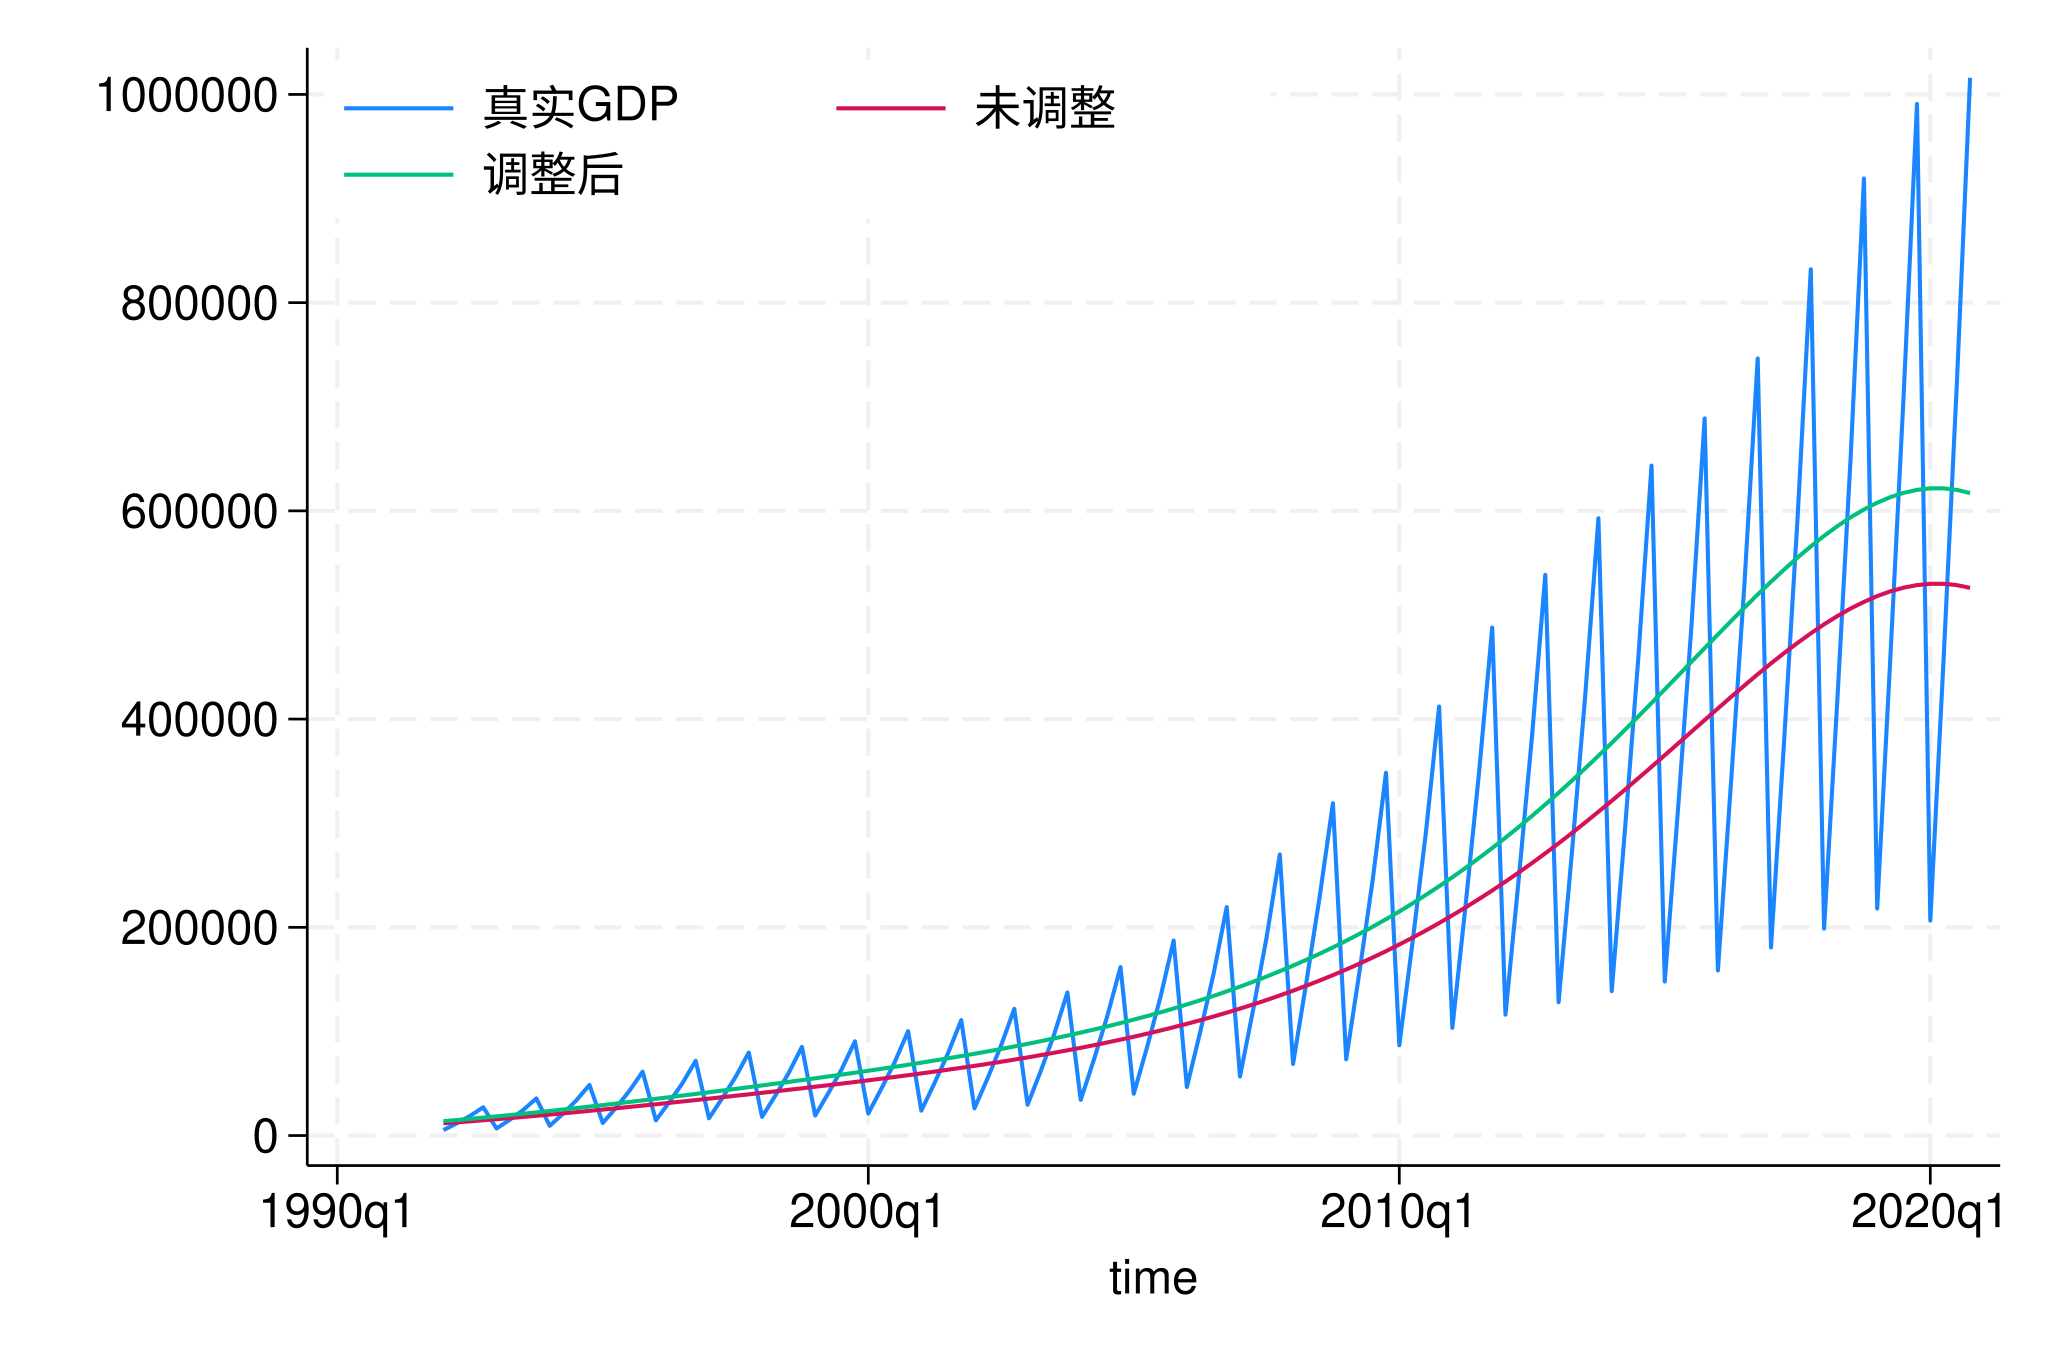

In [7]:
%%stata
tsline gdp predicted_gdp_unadjust predicted_gdp_adjust, legend(pos(11) ring(0))